# **Análisis Comparativo de las Regiones**

En este notebook se comparan las tres series de tiempo regionales (América del Centro, América del Norte y Europa) para responder, con evidencia estadística, cuál presenta mayor estacionalidad, mayor tendencia de crecimiento, mayor volatilidad y cuál fue la más afectada por la pandemia. Las tres primeras comparaciones se hacen sobre el período previo a la pandemia (2009-2019), para medir el comportamiento normal de cada serie sin que el desplome de 2020 distorsione los resultados, mientras que la última se enfoca justamente en el impacto pandémico. Para cada pregunta se usa una medida sencilla: la autocorrelación en el mes 12 para la estacionalidad, el porcentaje de crecimiento entre 2009 y 2019 para la tendencia, el coeficiente de variación para la volatilidad, y el porcentaje de caída de 2019 a 2020 para el impacto de la pandemia.

## **Setup**

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "analisisComparativo" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"

print("Setup completado")

Setup completado


## **Series y métricas comparativas**

Se cargan las tres series desde el conjunto de entrenamiento y se calcula, para cada una, la autocorrelación en el mes 12 (sobre la serie diferenciada, para que refleje la estacionalidad y no la tendencia), el porcentaje de crecimiento entre 2009 y 2019, el coeficiente de variación y el porcentaje de caída provocado por la pandemia.

In [4]:
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])
regiones = ["América Del Centro", "América Del Norte", "Europa"]

series = {}
for r in regiones:
    x = entrenamiento[entrenamiento["Región dos"] == r].groupby("Fecha")["Viajero"].sum().asfreq("MS")
    series[r] = x.fillna(x.min())

def metricas_comparativas(x):
    pre = x[(x.index >= "2009-01-01") & (x.index < "2020-01-01")]
    acf_mes_12 = acf(pre.diff().dropna(), nlags=12)[12]
    anual = pre.groupby(pre.index.year).sum()
    crecimiento = (anual.loc[2019] / anual.loc[2009] - 1) * 100
    cv = pre.std() / pre.mean()
    caida = (1 - x[x.index.year == 2020].min() / x[x.index.year == 2019].mean()) * 100
    return {
        "ACF_mes_12": round(acf_mes_12, 2),
        "crecimiento_%": round(crecimiento, 0),
        "CV": round(cv, 2),
        "caida_pandemia_%": round(caida, 1),
    }

comparativa = pd.DataFrame({r: metricas_comparativas(series[r]) for r in regiones}).T
display(comparativa)

,ACF_mes_12,crecimiento_%,CV,caida_pandemia_%
América Del Centro,0.55,155.0,0.36,96.4
América Del Norte,0.79,45.0,0.24,97.7
Europa,0.80,26.0,0.25,99.8


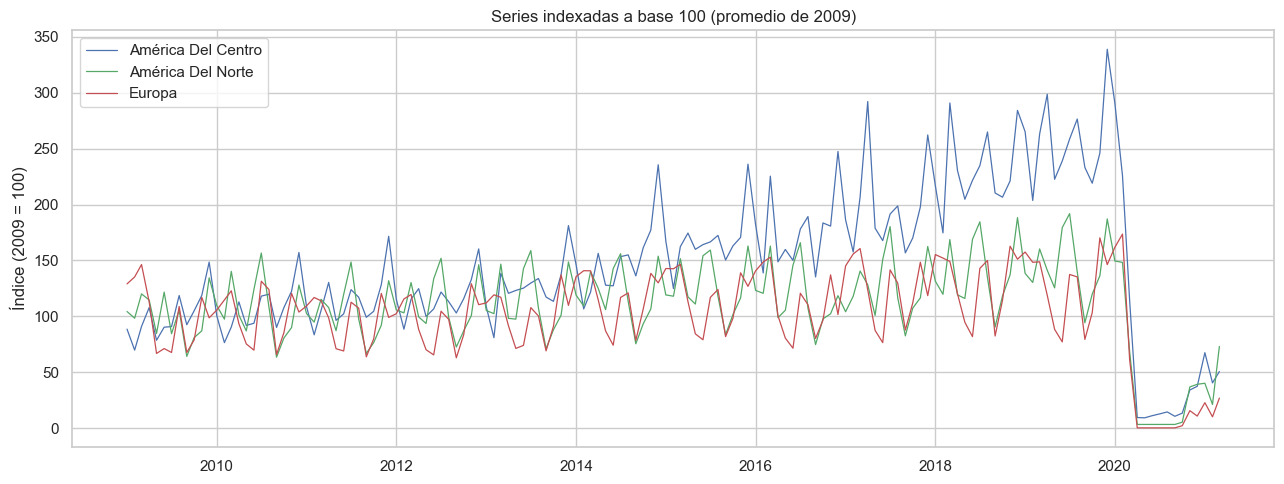

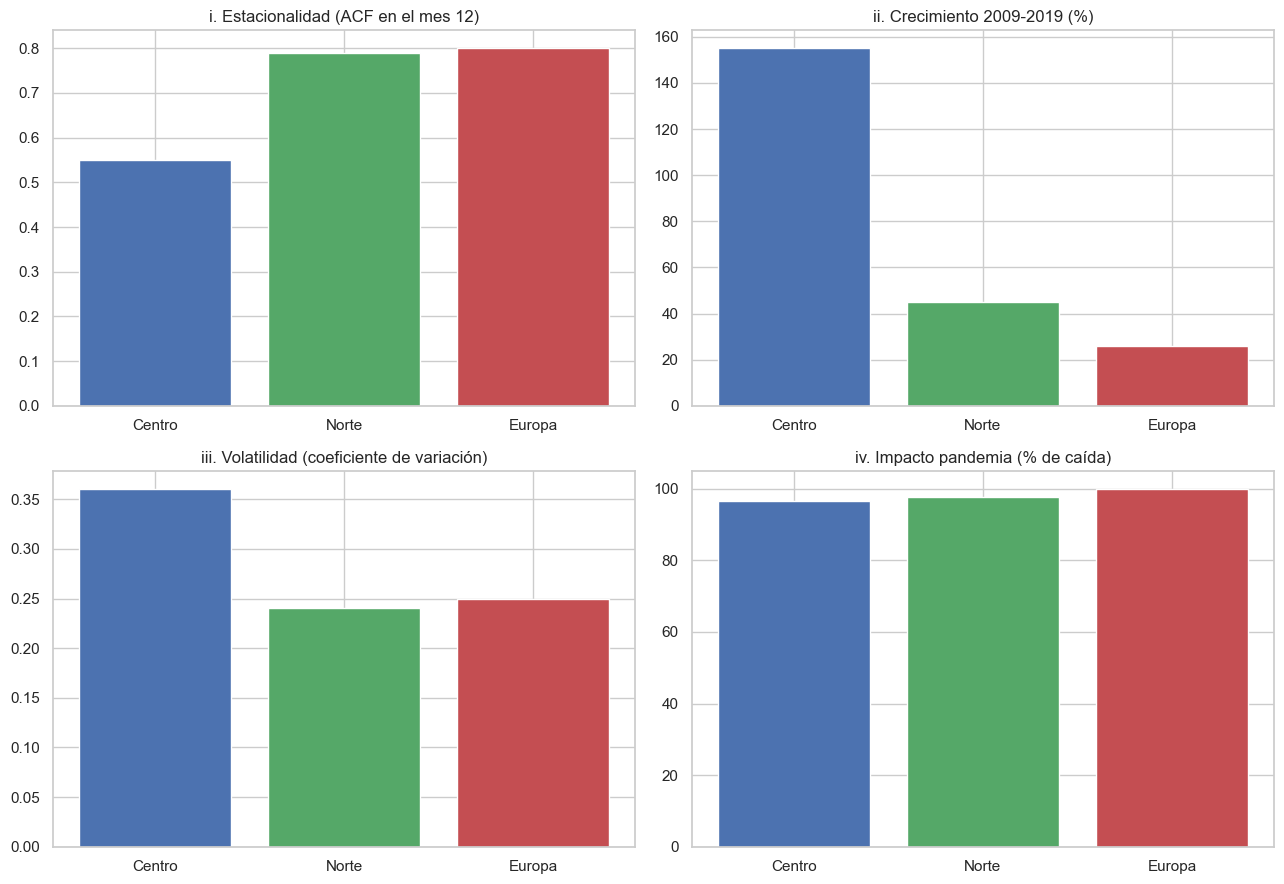

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for r, color in zip(regiones, ["#4C72B0", "#55A868", "#C44E52"]):
    x = series[r]
    ax.plot(x.index, x / x[x.index.year == 2009].mean() * 100, label=r, linewidth=0.9, color=color)
ax.set_title("Series indexadas a base 100 (promedio de 2009)")
ax.set_ylabel("Índice (2009 = 100)")
ax.legend()
plt.tight_layout()
plt.show()

etiquetas = ["Centro", "Norte", "Europa"]
colores = ["#4C72B0", "#55A868", "#C44E52"]
paneles = [
    ("ACF_mes_12", "i. Estacionalidad (ACF en el mes 12)"),
    ("crecimiento_%", "ii. Crecimiento 2009-2019 (%)"),
    ("CV", "iii. Volatilidad (coeficiente de variación)"),
    ("caida_pandemia_%", "iv. Impacto pandemia (% de caída)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, titulo) in zip(axes.flat, paneles):
    ax.bar(etiquetas, comparativa[col].values, color=colores)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

## **i. ¿Cuál presenta mayor estacionalidad?**

La serie que mayor estacionalidad presenta es Europa, sin embargo, esta está bastante cercana a los valores registrados para América del Norte. Esto tiene sentido, ya que son destinos que en Guatemala usualmente se transitan en fechas específicas, alrededor de lo que la mayoría de la gente toma como vacaciones, como podría ser a mitad de año o a finales de año. Esto hace que estas dos regiones tengan un valor tan alto de estacionalidad, ya que hay ciertos patrones claros que incluso sin ver la estadística podríamos inferir, dado que en esos momentos del año es donde más turismo se llega a encontrar hacia esos destinos.

En contraste, está América del Centro, que presenta menos estacionalidad que el norte y Europa, y a esto también podemos encontrarle sentido, debido a que es menos costoso y más fácil transitar hacia otros países centroamericanos estando en Guatemala, o que otra gente centroamericana venga a Guatemala, en comparación con visitar regiones más lejanas. Por ejemplo, en distintos puntos del año es común viajar hacia El Salvador por razones que no necesariamente son turismo, tal vez para visitar a un amigo o para dejar a alguien en el aeropuerto, de tal forma que ese flujo no se concentra en épocas específicas y por eso la estacionalidad resulta menor.

## **ii. ¿Cuál presenta mayor tendencia de crecimiento?**

Siguiendo la línea de lo mencionado en la pregunta anterior, la región con mayor crecimiento es América del Centro, le sigue América del Norte y por último Europa. Esto también se puede explicar desde un punto de vista lógico, ya que a nivel de recursos y de disponibilidad de tiempo es mucho más fácil viajar a Centroamérica; por ejemplo, en un fin de semana basta con cruzar la frontera si se toma la vía terrestre. En cambio, si se desea ir a Norteamérica los precios se elevan, usualmente se tiene que optar por la vía aérea y ya no es tan sencillo hacer ese tipo de viajes por carro, dado que la distancia aumenta. Y al irse hasta Europa estos factores se vuelven mucho más evidentes, razón por la cual se explica que Europa, de entre las tres, sea la que presenta el menor crecimiento de turismo.

## **iii. ¿Cuál presenta mayor volatilidad?**

América Central, esto se puede explicar debido a que fue la región que más creció, sus valores mensuales pasaron de un nivel bajo al inicio del período a uno bastante más alto al final, de tal forma que se dispersan mucho más alrededor de su promedio, y como el coeficiente de variación mide justamente esa dispersión respecto a la media, termina siendo el más alto. En otras palabras, su volatilidad no viene tanto de cambios bruscos mes a mes, sino de que su nivel de turismo creció tanto a lo largo de los años que su variación respecto al promedio es la mayor de las tres regiones.

## **iv. ¿Cuál fue la más afectada por la pandemia?**

El impacto de la pandemia se midió a través del porcentaje de caída, es decir, desde lo último que se registró en 2019 hasta el bajón que se tuvo en 2020 con el inicio de la pandemia. La región que mayor decaimiento en el turismo tuvo fue Europa, le sigue América del Norte y por último América del Centro. Esto tiene sentido si nos ponemos a pensar que, aunque fuera hacia Centroamérica todavía se podía viajar por vía terrestre, hacia Norteamérica y Europa era prácticamente imposible, ya que hubo una etapa en la que los aeropuertos estaban totalmente cerrados. Y dado que hacia Europa el turismo ya de por sí no era tan frecuentado, el hecho de cerrar los aeropuertos hizo que el turismo hacia allá quedara prácticamente nulo, razón por la cual fue la región más afectada.